# IGS-GA on DAS-CMOP: Example

This notebook shows how to use **IGS-GA** (IMAP Genetic Algorithm) to solve constrained multi-objective optimisation problems from the [DAS-CMOP benchmark suite](https://pymoo.org/problems/multi/dascmop.html).

- **DAS-CMOP1–6**: bi-objective, 30 decision variables, 11 constraints, difficulty 1–16
- **DAS-CMOP7–9**: tri-objective, 30 decision variables, 7 constraints, 16 difficulty-factor triplets

**IGS-GA** replaces NSGA-II's non-dominated sorting with IMAP affine aggregation, which incorporates stakeholder preference functions directly into the survival selection.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pymoo.optimize import minimize as pymoo_minimize
from pymoo.problems.multi.dascmop import (
    DASCMOP1, DASCMOP2, DASCMOP3,
    DASCMOP4, DASCMOP5, DASCMOP6,
    DASCMOP7, DASCMOP8, DASCMOP9,
)
from pymoo.termination import get_termination

from optimization.igs_ga import IGSGA

## Configuration

Edit the cell below to choose which DAS-CMOP problem to solve.

| Problems | Objectives | `difficulty` argument |
|---|---|---|
| `DASCMOP1` – `DASCMOP6` | 2 | integer `1–16` |
| `DASCMOP7` – `DASCMOP9` | 3 | list `[η1, η2, η3]`, each ηᵢ ∈ {0, 0.25, 0.5, 0.75, 1.0} |

In [33]:
# ── Choose your problem ───────────────────────────────────────────────────────
# Bi-objective (DASCMOP1–6): set PROBLEM_CLASS and DIFFICULTY (int 1–16).
# Tri-objective (DASCMOP7–9): set PROBLEM_CLASS and DIFFICULTY_FACTORS instead.

PROBLEM_CLASS      = DASCMOP1          # ← change to any DASCMOP1–DASCMOP9
DIFFICULTY         = 3                 # ← integer 1–16 (bi-objective only)
DIFFICULTY_FACTORS = [0.5, 0.5, 0.5]  # ← list of 3 floats  (tri-objective only)

# ── Run configuration ─────────────────────────────────────────────────────────
N_GEN    = 3000
POP_SIZE = 40
SEED     = 42

# ── Stakeholder configuration ─────────────────────────────────────────────────
# Keyed by n_obj so bi- and tri-objective problems use different setups.
# Each stakeholder dict supports:
#   "obj_weights"  – weight per objective (must sum to 1, length == n_obj)
#   "weight"       – importance of this stakeholder relative to others
#   "pref_shape"   – "linear" | "convex" | "concave" | "sigmoid"
#   "reverse"      – if True, flips the preference direction (higher obj = better)
STAKEHOLDERS: dict[int, list[dict]] = {
    # Bi-objective problems (DAS-CMOP 1–6)
    # 2: [
    #     {"obj_weights": [0.5, 0.5], "weight": 0.3, "pref_shape": "linear"},
    #     {"obj_weights": [0.5, 0.5], "weight": 0.7, "pref_shape": "linear", "reverse": True},
    # ],
    2: [
        {"obj_weights": [1.0, 0.0], "weight": 0.5, "pref_shape": "linear"},
        {"obj_weights": [0.0, 1.0], "weight": 0.5, "pref_shape": "linear"},
    ],
    # Tri-objective problems (DAS-CMOP 7–9)
    3: [
        {"obj_weights": [1/3, 1/3, 1/3], "weight": 0.6, "pref_shape": "linear"},
        {"obj_weights": [0.2, 0.3, 0.5],  "weight": 0.4, "pref_shape": "linear", "reverse": True},
    ],
}

## 1. Problem Setup

Instantiate the chosen DAS-CMOP problem using the parameters defined above.

In [34]:
_TRI_NAMES = {"DASCMOP7", "DASCMOP8", "DASCMOP9"}
is_tri = PROBLEM_CLASS.__name__ in _TRI_NAMES

if is_tri:
    problem = PROBLEM_CLASS(difficulty_factors=DIFFICULTY_FACTORS) # type: ignore
else:
    problem = PROBLEM_CLASS(difficulty=DIFFICULTY) # type: ignore

print(f"Problem  : {PROBLEM_CLASS.__name__}  ({'tri' if is_tri else 'bi'}-objective)")
print(f"n_var    : {problem.n_var}")
print(f"n_obj    : {problem.n_obj}")
print(f"n_constr : {problem.n_constr}")

Problem  : DASCMOP1  (bi-objective)
n_var    : 30
n_obj    : 2
n_constr : 11


## 2. Preference Functions

IMAP aggregation converts raw objective values into preference scores in **[0, 100]**, where **higher is better**.

Objective bounds are derived analytically from the problem structure using `get_das_cmop_bounds`, which covers all DAS-CMOP1–9 variants. The `STAKEHOLDERS` dict defined in the configuration cell is parsed by `build_imap_config` into the three inputs required by IGS-GA.

Each stakeholder entry supports:
- `obj_weights` — per-objective weight (must sum to 1)
- `weight` — importance of this stakeholder relative to others
- `pref_shape` — shape of the preference function: `"linear"` | `"convex"` | `"concave"` | `"sigmoid"`
- `reverse` — if `True`, flips the preference direction (higher objective value = better)

A **constraint-violation preference function** is also provided so that infeasible solutions are always deprioritised during selection.

In [35]:
def get_das_cmop_bounds(problem) -> list[tuple[float, float]]:
    """Return analytical [lo, hi] per objective for DAS-CMOP1-9."""
    n = problem.n_var
    m = problem.n_obj
    k = n - (m - 1)  # number of distance-function terms
    name = problem.__class__.__name__.upper()

    if any(p in name for p in ["DASCMOP1", "DASCMOP2", "DASCMOP3", "DASCMOP9"]):
        # g = Σ (xⱼ - shift)², max per term = 1
        g_min, g_max = 0.0, float(k)
    elif any(p in name for p in ["DASCMOP4", "DASCMOP5", "DASCMOP6", "DASCMOP7", "DASCMOP8"]):
        # g = k + Σ ((xⱼ-0.5)² - cos(20π(xⱼ-0.5))), max per term ≈ 1.2025
        g_min, g_max = 0.0, k * (1 + 1.2025)
    else:
        raise ValueError(f"Unknown DAS-CMOP problem: {name}")

    # f2 of DASCMOP3/DASCMOP6 has a shape function that peaks at ≈ 1.184
    shape_maxes = []
    for i in range(m):
        if i == 1 and any(p in name for p in ["DASCMOP3", "DASCMOP6"]):
            shape_maxes.append(1.5 - 1.0 / 10**0.5)  # ≈ 1.184
        else:
            shape_maxes.append(1.0)

    return [(0.0 + g_min, s_max + g_max) for s_max in shape_maxes]


def build_pref_fn(lo: float, hi: float, shape: str = "linear", reverse: bool = False):
    """
    Build a preference function mapping a raw objective value → score in [0, 100].

    Parameters
    ----------
    lo, hi   : objective bounds (lo = best possible, hi = worst possible for minimisation)
    shape    : "linear" | "convex" | "concave" | "sigmoid"
    reverse  : when True, flips the preference direction (higher raw value = better)
    """
    def _fn(x: float) -> float:
        t = float(np.clip((hi - x) / (hi - lo), 0.0, 1.0))  # t=1 → best
        if reverse:
            t = 1.0 - t
        if shape == "linear":
            return t * 100.0
        elif shape == "convex":
            return t ** 2 * 100.0
        elif shape == "concave":
            return t ** 0.5 * 100.0
        elif shape == "sigmoid":
            return float(100.0 / (1.0 + np.exp(-10.0 * (t - 0.5))))
        else:
            raise ValueError(f"Unknown pref_shape: {shape!r}")
    return _fn


def build_imap_config(n_obj, obj_bounds, obj_names, stakeholder_configs):
    """
    Convert a STAKEHOLDERS config list into the three dicts expected by IGSGA.

    Returns
    -------
    preference_functions : dict[int, dict[str, Callable]]
    objective_weights    : dict[int, dict[str, float]]
    stakeholder_weights  : list[float]
    """
    preference_functions = {}
    objective_weights    = {}
    stakeholder_weights  = []

    for sid, cfg in enumerate(stakeholder_configs, 1):
        shape   = cfg.get("pref_shape", "linear")
        reverse = cfg.get("reverse", False)
        w_list  = cfg["obj_weights"]

        preference_functions[sid] = {
            name: build_pref_fn(lo, hi, shape=shape, reverse=reverse)
            for name, (lo, hi) in zip(obj_names, obj_bounds)
        }
        objective_weights[sid] = dict(zip(obj_names, w_list))
        stakeholder_weights.append(cfg["weight"])

    return preference_functions, objective_weights, stakeholder_weights


# ── Constraint-violation preference function ──────────────────────────────────
# cv = 0 → 100 (feasible),  cv → ∞ → 0 (heavily infeasible)
def cv_pref_fn(cv: float) -> float:
    return float(100.0 / (1.0 + 10.0 * cv))


# ── Compute bounds and build IMAP config ──────────────────────────────────────
obj_names  = [f"f{j+1}" for j in range(problem.n_obj)]
obj_bounds = get_das_cmop_bounds(problem)
for name, (lo, hi) in zip(obj_names, obj_bounds):
    print(f"  {name} ∈ [{lo:.4f}, {hi:.4f}]")

stakeholder_configs = STAKEHOLDERS.get(
    problem.n_obj,
    [{"obj_weights": [1 / problem.n_obj] * problem.n_obj, "weight": 1.0, "pref_shape": "linear"}],
)
preference_functions, objective_weights, stakeholder_weights = build_imap_config(
    problem.n_obj, obj_bounds, obj_names, stakeholder_configs
)

print(f"\n{len(stakeholder_configs)} stakeholder(s) configured:")
for i, cfg in enumerate(stakeholder_configs, 1):
    print(f"  [{i}] weight={cfg['weight']}, obj_weights={cfg['obj_weights']}, "
          f"pref_shape={cfg.get('pref_shape','linear')}, reverse={cfg.get('reverse', False)}")

  f1 ∈ [0.0000, 30.0000]
  f2 ∈ [0.0000, 30.0000]

2 stakeholder(s) configured:
  [1] weight=0.5, obj_weights=[1.0, 0.0], pref_shape=linear, reverse=False
  [2] weight=0.5, obj_weights=[0.0, 1.0], pref_shape=linear, reverse=False


## 3. Run IGS-GA

Configure and run **IGS-GA** on the problem.

Key parameters:
- `pop_size`: population size per generation
- `tournament_selection`: use binary tournament (vs. truncation) for survival
- `archive`: maintain a cross-generation archive to stabilise IMAP scoring
- `cv_pref_fn` / `cv_weight`: give 50 % of the aggregation weight to constraint satisfaction, so infeasible individuals are always dominated by feasible ones

In [36]:
algorithm = IGSGA(
    preference_functions=preference_functions,
    objective_weights=objective_weights,
    stakeholder_weights=stakeholder_weights,
    all_objectives=obj_names,
    pop_size=POP_SIZE,
    tournament_selection=True,
    archive=True,
    cv_pref_fn=cv_pref_fn,
    cv_weight=0.5,
    seed=SEED,
    verbose=False,
)

res = pymoo_minimize(
    problem,
    algorithm,
    get_termination("n_gen", N_GEN),
    seed=SEED,
    verbose=False,
    copy_algorithm=False,
)

print("Optimisation complete.")
print(f"Best solution found at generation : {res.algorithm.current_best_gen}") # type: ignore

best = res.algorithm.current_best # type: ignore
best_F = best.get("F").flatten()
best_G = best.get("G").flatten()
cv = float(np.sum(np.maximum(0.0, best_G)))

obj_str = ", ".join(f"f{i+1}={v:.4f}" for i, v in enumerate(best_F))
print(f"Objective values  : {obj_str}")
print(f"Constraint violation (cv): {cv:.6f}  {'feasible' if cv <= 1e-9 else 'infeasible'}")

Optimisation complete.
Best solution found at generation : 2999
Objective values  : f1=1.1122, f2=1.6606
Constraint violation (cv): 0.000000  feasible


## 4. Results

### 4a. Best solution in objective space

Feasible solutions from the final population are shown in blue. The reference Pareto front (from pymoo) is shown in grey. The IMAP-selected best solution is marked with ★.

Final population : 40 individuals, 40 feasible


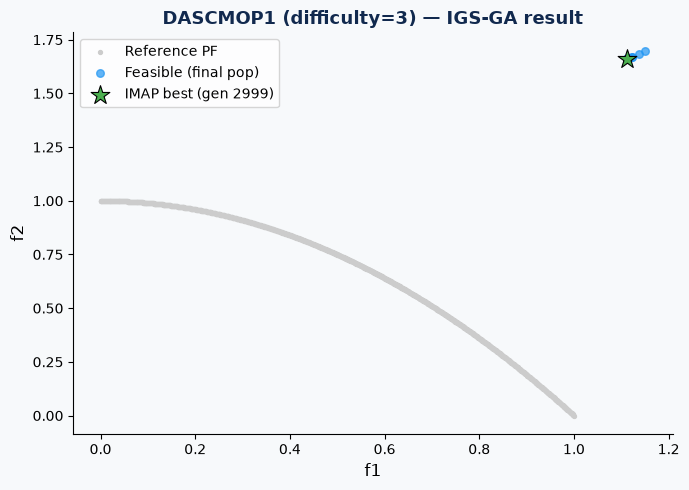

In [40]:
# ── Extract feasible solutions from the final population ─────────────────────
X_final = res.pop.get("X")
pop_out = problem.evaluate(X_final, return_as_dictionary=True)
F_all = pop_out["F"]
G_all = pop_out["G"]

cv_all = np.sum(np.maximum(0.0, G_all), axis=1)
feasible_mask = cv_all <= 1e-9
F_feasible = F_all[feasible_mask]
print(f"Final population : {len(F_all)} individuals, {feasible_mask.sum()} feasible")

# ── Reference Pareto front (from pymoo) ───────────────────────────────────────
try:
    pf = problem.pareto_front()
except Exception:
    pf = None

# ── Plot ──────────────────────────────────────────────────────────────────────
prob_label = PROBLEM_CLASS.__name__
diff_label = f"difficulty_factors={DIFFICULTY_FACTORS}" if is_tri else f"difficulty={DIFFICULTY}"
title = f"{prob_label} ({diff_label}) — IGS-GA result"

if problem.n_obj == 2:
    fig, ax = plt.subplots(figsize=(7, 5))
    if pf is not None:
        ax.scatter(pf[:, 0], pf[:, 1], s=8, color="#cccccc", label="Reference PF", zorder=1)
    if len(F_feasible) > 0:
        ax.scatter(F_feasible[:, 0], F_feasible[:, 1],
                   s=30, color="#2196F3", alpha=0.7, label="Feasible (final pop)", zorder=2)
    ax.scatter(best_F[0], best_F[1], s=200, color="#4CAF50", marker="*",
               edgecolors="black", linewidths=0.8,
               label=f"IMAP best (gen {res.algorithm.current_best_gen})", zorder=3)
    ax.set_xlabel("f1", fontsize=12)
    ax.set_ylabel("f2", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold", color="#11294e")
    ax.legend(fontsize=10)
    ax.set_facecolor("#f7f9fb")
    ax.spines[["top", "right"]].set_visible(False)
else:
    # Tri-objective: show three 2-D projections
    pairs = [(0, 1), (0, 2), (1, 2)]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (i, j) in zip(axes, pairs):
        xi, xj = obj_names[i], obj_names[j]
        if pf is not None:
            ax.scatter(pf[:, i], pf[:, j], s=8, color="#cccccc", label="Reference PF", zorder=1)
        if len(F_feasible) > 0:
            ax.scatter(F_feasible[:, i], F_feasible[:, j],
                       s=30, color="#2196F3", alpha=0.7, label="Feasible (final pop)", zorder=2)
        ax.scatter(best_F[i], best_F[j], s=200, color="#4CAF50", marker="*",
                   edgecolors="black", linewidths=0.8,
                   label=f"IMAP best (gen {res.algorithm.current_best_gen})", zorder=3)
        ax.set_xlabel(xi, fontsize=11)
        ax.set_ylabel(xj, fontsize=11)
        ax.legend(fontsize=8)
        ax.set_facecolor("#f7f9fb")
        ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight="bold", color="#11294e")

fig.patch.set_facecolor("#f7f9fb")
plt.tight_layout()
plt.show()

### 4b. Preference functions

For each objective, the configured preference curves are plotted over the full bounds range. The ★ marks where the IMAP-selected best solution falls on each curve.

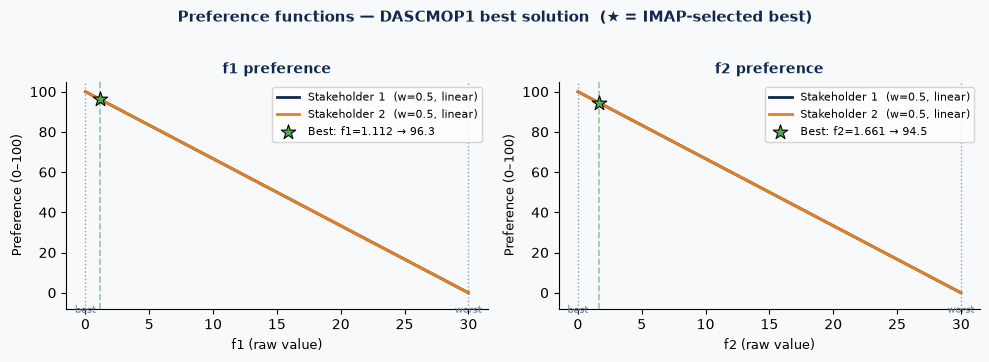

In [42]:
palette = ["#11294e", "#e67e22", "#8e44ad", "#27ae60", "#e74c3c"]

fig, axes = plt.subplots(1, problem.n_obj, figsize=(5 * problem.n_obj, 3.5))
if problem.n_obj == 1:
    axes = [axes]

for j, (ax, obj) in enumerate(zip(axes, obj_names)):
    lo, hi = obj_bounds[j]
    xs = np.linspace(lo, hi, 300)

    for sid, cfg in enumerate(stakeholder_configs, 1):
        pf_fn = preference_functions[sid][obj]
        ys = [pf_fn(x) for x in xs]
        ax.plot(xs, ys, color=palette[(sid - 1) % len(palette)], linewidth=2,
                label=f"Stakeholder {sid}  (w={cfg['weight']}, {cfg.get('pref_shape', 'linear')})")

    # Mark where the best solution falls (on stakeholder 1's curve)
    best_val  = float(best_F[j])
    best_pref = preference_functions[1][obj](best_val)
    ax.scatter([best_val], [best_pref], s=120, color="#4CAF50", marker="*",
               edgecolors="black", linewidths=0.8, zorder=5,
               label=f"Best: {obj}={best_val:.3f} → {best_pref:.1f}")
    ax.axvline(best_val, color="#4CAF50", linestyle="--", linewidth=1.2, alpha=0.6, zorder=3)

    for x_bound, lbl in [(lo, "best"), (hi, "worst")]:
        ax.axvline(x_bound, color="#6b7a8d", linestyle=":", linewidth=1, alpha=0.7)
        ax.text(x_bound, -6, lbl, ha="center", va="top", fontsize=7.5, color="#6b7a8d")

    ax.set_xlabel(f"{obj} (raw value)", fontsize=9)
    ax.set_ylabel("Preference (0–100)", fontsize=9)
    ax.set_title(f"{obj} preference", fontsize=10, fontweight="bold", color="#11294e")
    ax.set_ylim(-8, 105)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_facecolor("#f7f9fb")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Preference functions — {PROBLEM_CLASS.__name__} best solution  (★ = IMAP-selected best)",
    fontsize=11, fontweight="bold", color="#11294e", y=1.02,
)
fig.patch.set_facecolor("#f7f9fb")
fig.tight_layout()
plt.show()